In [1]:
"""
Plot each compact-model calibration parameter against z across the calibrated
nodes (black dots) and the cubic-spline-interp/linear-tail-extrapolation curve
(_compact_params) out past the calibrated edge, to eyeball whether the
extrapolation to z=1.317/1.491 looks like a sane continuation or an artifact
of only having 4 calibration points.
"""

import warnings
import numpy as np
import matplotlib.pyplot as plt
from compact.config import Config
from compact.predictions import CompactStreamingModel

cfg = Config()
z_nodes = sorted(cfg.compact_emulator.keys())

In [2]:
theta_base = np.array([1.0, 0.0, 0.0224, 0.12, 0.68, 2.1e-9, 0.9649])
for ns in [0.92, 0.9649, 0.98]:
    theta = theta_base.copy(); theta[6] = ns
    xi = CompactStreamingModel(redshift=0.510, config=cfg).predict(theta, ells=(0,))
    print(ns, xi[0][:5])

/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/LPT/cleft_fftw.py:125: RuntimeWarning: overflow encountered in exp
  expon = np.exp(-0.5*ksq * (self.XYlin - self.sigma))
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/LPT/cleft_fftw.py:126: RuntimeWarning: overflow encountered in expm1
  exponm1 = np.expm1(-0.5*ksq * (self.XYlin - self.sigma))
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/LPT/cleft_fftw.py:162: RuntimeWarning: overflow encountered in multiply
  bias_integrands = bias_integrands * expon
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/Utils/spherical_bessel_transform_fftw.py:99: RuntimeWarning: overflow encountered in multiply
  self.fs[:,self.Npad - self.Npad//2 : self.N - self.Npad//2] = fq * self.q**(3-q)
/home/cosweeney/miniconda3/envs/scienv/lib/python3.12/site-packages/velocileptors/LPT/cleft_fftw.py:165: RuntimeWarning: overflow

0.92 [0.42568455 0.37740397 0.33636927 0.30118729 0.27079213]
0.9649 [0.41811993 0.36976443 0.3287676  0.29369844 0.2634657 ]
0.98 [0.41563272 0.36724667 0.32625913 0.29122559 0.26104586]


/tmp/ipykernel_2061372/1117602065.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


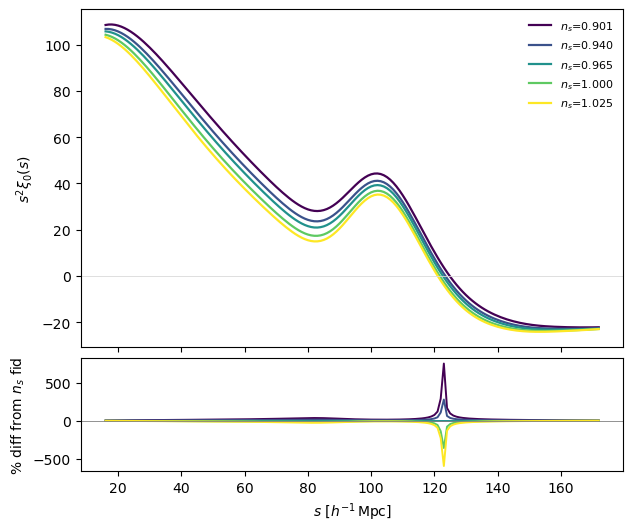

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from compact.predictions import CompactStreamingModel
from compact.config import Config

cfg = Config()
z = 0.510

# hold everything else fixed at a representative point, vary only n_s
theta_base = np.array([1.0, 0.0, 0.02237, 0.1200, 0.6777, 2.0830e-9, 0.9649])
ns_values = [0.901, 0.940, 0.9649, 1.000, 1.025]   # spans the AbacusSummit range

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                                     gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

xi0_fid = None
colors = plt.cm.viridis(np.linspace(0, 1, len(ns_values)))

for ns, c in zip(ns_values, colors):
    theta = theta_base.copy()
    theta[6] = ns
    model = CompactStreamingModel(redshift=z, config=cfg)
    xi0 = model.predict(theta, ells=(0,))[0]

    ax_top.plot(cfg.r, cfg.r**2 * xi0, color=c, lw=1.6, label=f'$n_s$={ns:.3f}')
    if np.isclose(ns, 0.9649):
        xi0_fid = xi0

for ns, c in zip(ns_values, colors):
    theta = theta_base.copy()
    theta[6] = ns
    model = CompactStreamingModel(redshift=z, config=cfg)
    xi0 = model.predict(theta, ells=(0,))[0]
    if xi0_fid is not None:
        ax_bot.plot(cfg.r, 100 * (xi0 - xi0_fid) / np.abs(xi0_fid), color=c, lw=1.4)

ax_top.axhline(0, color='0.85', lw=0.6)
ax_top.set_ylabel(r'$s^2\xi_0(s)$')
ax_top.legend(frameon=False, fontsize=8)
ax_bot.axhline(0, color='0.5', lw=0.6)
ax_bot.set_ylabel('% diff from $n_s$ fid')
ax_bot.set_xlabel(r'$s\ [h^{-1}\,\mathrm{Mpc}]$')
fig.tight_layout()

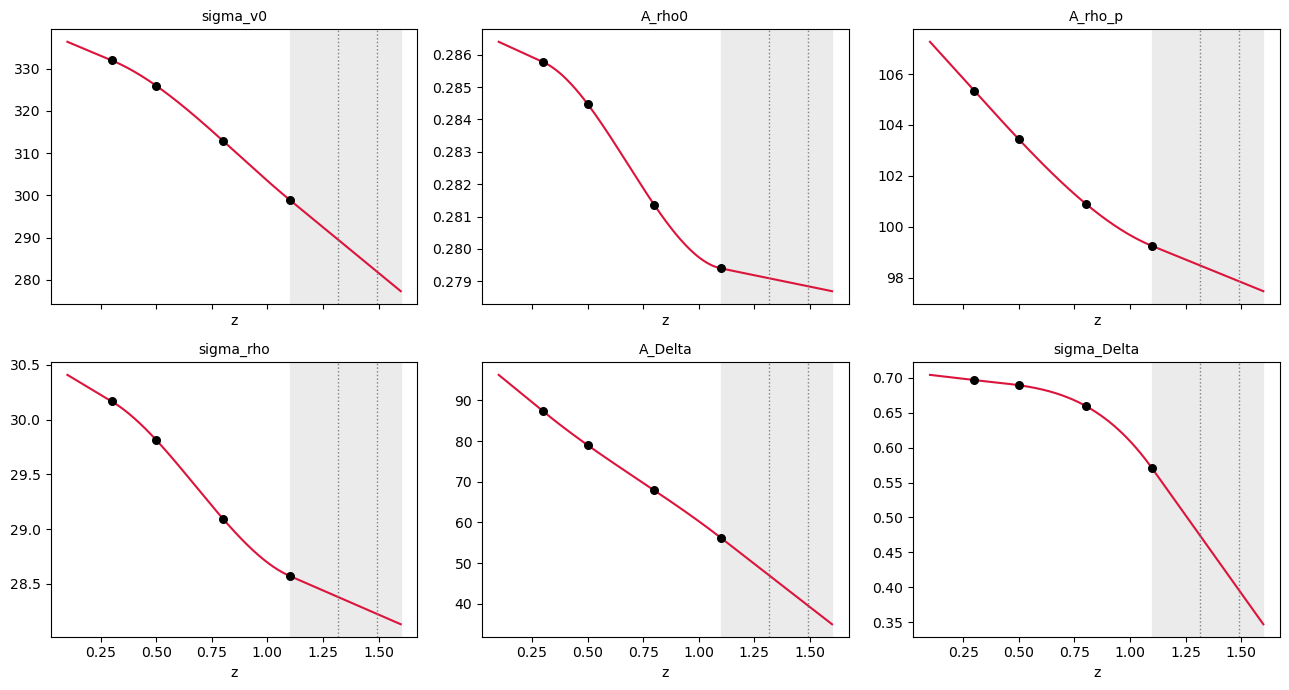

In [3]:
# fiducial cosmology, matching Config.FIDUCIAL_COSMO's (ombh2, omch2, As) with an
# arbitrary h -- background-independent choice, just needs to be inside the prior
cosmo_theta = (0.6777, 0.02237, 0.1200, 2.0830e-9)   # (h, ombh2, omch2, As)

param_names = ['sigma_v0', 'A_rho0', 'A_rho_p', 'sigma_rho', 'A_Delta', 'sigma_Delta']

with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # suppress the per-call out-of-range warning here

    node_vals = np.array([CompactStreamingModel(redshift=z, config=cfg)._compact_params(cosmo_theta)
                          for z in z_nodes])

    z_dense = np.linspace(0.1, 1.6, 300)
    dense_vals = np.array([CompactStreamingModel(redshift=z, config=cfg)._compact_params(cosmo_theta)
                           for z in z_dense])

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for i, (ax, name) in enumerate(zip(axes.flat, param_names)):
    ax.plot(z_dense, dense_vals[:, i], color='crimson', lw=1.5)
    ax.scatter(z_nodes, node_vals[:, i], color='k', zorder=5, s=30)
    ax.axvspan(z_nodes[-1], 1.6, color='0.92', zorder=0)   # extrapolation region
    ax.axvline(1.317, color='0.5', ls=':', lw=1)
    ax.axvline(1.491, color='0.5', ls=':', lw=1)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('z')
fig.tight_layout()
